# Genre Classifier
Trains **Logistic Regression** and **SVM** models to classify book genre from
100-word text partitions.

**Inputs required (run the other notebooks first):**
- `partitions.csv` — from `book_partitioner.ipynb`
- `vocabulary.csv` — from `book_ngram_analysis.ipynb`

**Outputs:** accuracy scores, classification reports, and confusion matrices.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import joblib


## Configuration

In [84]:
PARTITIONS_CSV = "partitions.csv"   # output of book_partitioner.ipynb
VOCABULARY_CSV = "vocabulary.csv"   # output of book_ngram_analysis.ipynb

TEST_SIZE      = 0.2    # 80/20 train-test split
RANDOM_STATE   = 42
CV_FOLDS       = 10      # stratified k-fold cross-validation

# Genres in a consistent display order
GENRES = ["autobiography", "fantasy", "horror", "romance", "sci-fi"]


## Load Data

In [85]:
partitions = pd.read_csv(PARTITIONS_CSV)
vocabulary  = pd.read_csv(VOCABULARY_CSV)["word"].tolist()

print(f"Partitions loaded : {len(partitions):,} rows")
print(f"Vocabulary size   : {len(vocabulary):,} words")
print(f"\nGenre distribution:")
print(partitions['genre'].value_counts().to_string())
partitions.head(3)


Partitions loaded : 1,000 rows
Vocabulary size   : 302 words

Genre distribution:
genre
fantasy          200
romance          200
sci-fi           200
horror           200
autobiography    200


,partition_id,book,genre,start_token,text,word_count
0,TheWonderfulWizardOfOz_partition_a,TheWonderfulWizardOfOz,fantasy,7296,"at the tin legs, which hurt his teeth. “Did yo...",100
1,TheWonderfulWizardOfOz_partition_b,TheWonderfulWizardOfOz,fantasy,1639,her eyes growing bigger and bigger at the wond...,100
2,TheWonderfulWizardOfOz_partition_c,TheWonderfulWizardOfOz,fantasy,18024,him your message. He said he will grant you an...,100


## Build Feature Matrix
We use **TF-IDF** restricted to the vocabulary derived from the n-gram analysis.
This ensures the features are exactly the top-100 unigrams we identified per book,
de-duplicated into a shared vocabulary.

In [86]:
X_text = partitions["text"].tolist()
y      = partitions["genre"].tolist()

# TF-IDF restricted to our pre-built vocabulary
vectorizer = TfidfVectorizer(
    vocabulary    = vocabulary,
    sublinear_tf  = True,      # apply log(1+tf) — reduces impact of very frequent words
    strip_accents = 'unicode',
    analyzer      = 'word',
    token_pattern = r'[a-z]+',
    lowercase     = True,
)

X = vectorizer.fit_transform(X_text)
print(f"Feature matrix shape: {X.shape}")
print(f"  {X.shape[0]} partitions  ×  {X.shape[1]} vocabulary features")


Feature matrix shape: (1000, 302)
  1000 partitions  ×  302 vocabulary features


## Train / Test Split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,      # preserve genre proportions in both splits
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 800
Test samples     : 200


## Model 1 — Logistic Regression

In [88]:
lr = LogisticRegression(
    max_iter      = 1000,
    random_state  = RANDOM_STATE,
    C             = 1.0,
    solver        = 'lbfgs',
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=" * 50)
print(" Logistic Regression — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=GENRES))


 Logistic Regression — Test Set
Accuracy: 0.9550

               precision    recall  f1-score   support

autobiography       0.86      0.95      0.90        40
      fantasy       0.98      1.00      0.99        40
       horror       1.00      0.93      0.96        40
      romance       0.95      0.90      0.92        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.95       200
    macro avg       0.96      0.96      0.96       200
 weighted avg       0.96      0.95      0.96       200



## Model 2 — Support Vector Machine

In [89]:
svm = LinearSVC(
    max_iter     = 2000,
    random_state = RANDOM_STATE,
    C            = 1.0,
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=" * 50)
print(" SVM (LinearSVC) — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=GENRES))


 SVM (LinearSVC) — Test Set
Accuracy: 0.9650

               precision    recall  f1-score   support

autobiography       0.88      0.95      0.92        40
      fantasy       0.98      1.00      0.99        40
       horror       0.97      0.95      0.96        40
      romance       1.00      0.93      0.96        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.96       200
    macro avg       0.97      0.97      0.97       200
 weighted avg       0.97      0.96      0.97       200



## 10-Fold Cross-Validation Comparison
Stratified 10-fold CV gives a more reliable accuracy estimate than a single train/test split.
With 1000 total partitions each fold uses ~900 for training and ~100 for testing,
and the genre balance is preserved in every fold.
Results are shown as mean ± std and visualised per fold so you can spot any unstable folds.

Logistic Regression
  Mean accuracy : 0.9480
  Std deviation : 0.0209
  Per-fold      : [0.91 0.94 0.93 0.98 0.94 0.97 0.97 0.96 0.93 0.95]

SVM
  Mean accuracy : 0.9410
  Std deviation : 0.0288
  Per-fold      : [0.9  0.97 0.91 0.97 0.93 0.97 0.93 0.97 0.9  0.96]



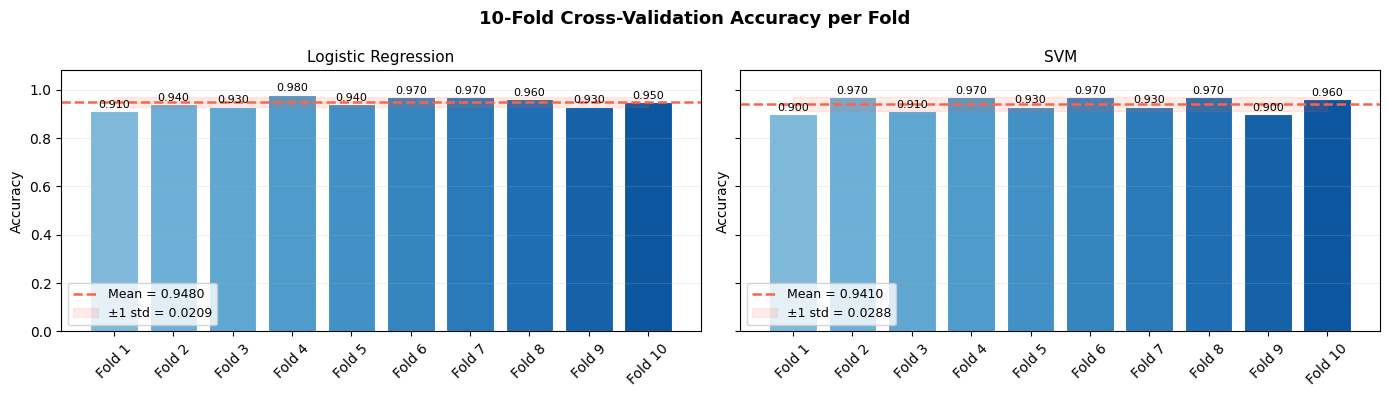

Saved: cv_accuracy_per_fold.png


In [90]:
from sklearn.model_selection import cross_val_score

kfold = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in [("Logistic Regression", lr), ("SVM", svm)]:
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}")
    print(f"  Mean accuracy : {scores.mean():.4f}")
    print(f"  Std deviation : {scores.std():.4f}")
    print(f"  Per-fold      : {np.round(scores, 4)}")
    print()

# ── Per-fold accuracy bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle(f"{CV_FOLDS}-Fold Cross-Validation Accuracy per Fold",
             fontsize=13, fontweight='bold')

fold_labels = [f"Fold {i+1}" for i in range(CV_FOLDS)]
colors = plt.cm.Blues(np.linspace(0.45, 0.85, CV_FOLDS))

for ax, (name, scores) in zip(axes, cv_results.items()):
    bars = ax.bar(fold_labels, scores, color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(scores.mean(), color='tomato', linewidth=1.8,
               linestyle='--', label=f'Mean = {scores.mean():.4f}')
    ax.fill_between(range(CV_FOLDS),
                    scores.mean() - scores.std(),
                    scores.mean() + scores.std(),
                    alpha=0.12, color='tomato', label=f'±1 std = {scores.std():.4f}')
    # Annotate bars
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{score:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cv_accuracy_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_accuracy_per_fold.png')


## Confusion Matrices
Each cell shows how many test partitions were assigned to each predicted genre.
Off-diagonal cells are misclassifications — useful for spotting which genres
get confused with each other.

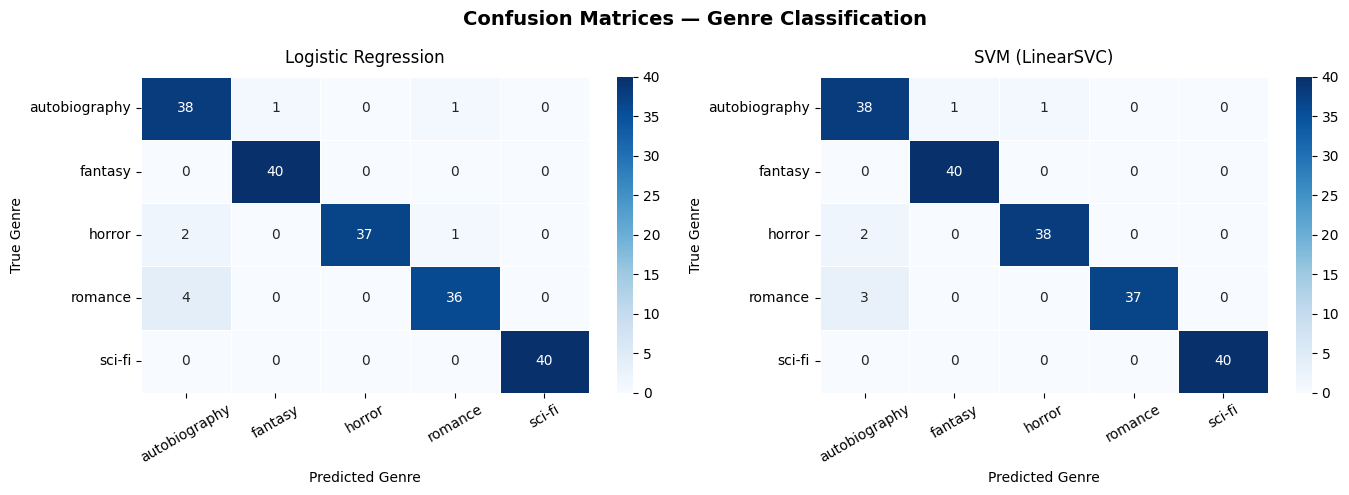

Saved: confusion_matrices.png


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — Genre Classification", fontsize=14, fontweight='bold')

for ax, y_pred, title in [
    (axes[0], y_pred_lr,  "Logistic Regression"),
    (axes[1], y_pred_svm, "SVM (LinearSVC)"),
]:
    cm = confusion_matrix(y_test, y_pred, labels=GENRES)
    sns.heatmap(
        cm,
        annot        = True,
        fmt          = 'd',
        cmap         = 'Blues',
        xticklabels  = GENRES,
        yticklabels  = GENRES,
        linewidths   = 0.5,
        ax           = ax,
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Predicted Genre", fontsize=10)
    ax.set_ylabel("True Genre", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")


## Error Analysis
Inspect the actual misclassified partitions to understand *why* genres get confused.

In [92]:
def error_analysis(model_name, y_pred):
    """Print misclassified partitions with their true and predicted genres."""
    # Align predictions back to the original partition rows used in the test split
    test_indices = partitions.index[
        partitions.index.isin(
            partitions.iloc[
                list(range(len(partitions)))
            ].index
        )
    ]

    # Rebuild a results frame from the test split
    _, X_test_raw, _, y_test_raw = train_test_split(
        partitions['text'].values, partitions['genre'].values,
        test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=partitions['genre'].values
    )

    errors = pd.DataFrame({
        'text':      X_test_raw,
        'true':      y_test_raw,
        'predicted': y_pred,
    })
    errors = errors[errors['true'] != errors['predicted']]

    print(f"\n{'='*60}")
    print(f"  {model_name} — {len(errors)} misclassified partitions")
    print(f"{'='*60}")
    print(errors.groupby(['true','predicted']).size().rename('count').to_string())
    print(f"\n--- Sample misclassifications (up to 3 per pair) ---")
    for (true, pred), group in errors.groupby(['true','predicted']):
        for _, row in group.head(3).iterrows():
            print(f"\n[True: {true}] → [Predicted: {pred}]")
            print(f"  {row['text'][:200]}...")

error_analysis("Logistic Regression", y_pred_lr)
error_analysis("SVM", y_pred_svm)





  Logistic Regression — 9 misclassified partitions
true           predicted    
autobiography  fantasy          1
               romance          1
horror         autobiography    2
               romance          1
romance        autobiography    4

--- Sample misclassifications (up to 3 per pair) ---

[True: autobiography] → [Predicted: fantasy]
  and prudent in the conduct of life; and little or no notice was ever taken of what related to the victuals on the table, whether it was well or ill dressed, in or out of season, of good or bad flavor,...

[True: autobiography] → [Predicted: romance]
  a friendly concern for thy welfare, to have no acquaintance with them." As I seem'd at first not to think so ill of them as she did, she mentioned some things she had observ'd and heard that had escap...

[True: horror] → [Predicted: autobiography]
  a fellow professor, would lecture upon chemistry the alternate days that he omitted. I returned home not disappointed, for I have said that I ha

SHAP of Error Analysis on LR

## SHAP Explainability — Logistic Regression

Our error analysis showed romance and autobiography are the most confused pair
(5 misclassifications between them). We use SHAP to explain exactly which words
pushed the model towards the wrong genre for these misclassified chunks.

SHAP (SHapley Additive exPlanations) assigns each word a score showing how much
it pushed the prediction towards or away from each genre.
- Positive SHAP value → word pushed prediction towards that genre
- Negative SHAP value → word pushed prediction away from that genre

In [93]:
#Setup SHAP Explainer

import shap

# Rebuild test split with raw text to identify misclassified chunks
_, X_test_raw, _, y_test_raw = train_test_split(
    partitions['text'].values, partitions['genre'].values,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=partitions['genre'].values
)

# Build a dataframe of test results
test_df = pd.DataFrame({
    'text':      X_test_raw,
    'true':      y_test_raw,
    'predicted': y_pred_lr,
})

# Filter to romance chunks misclassified as autobiography
confused = test_df[
    (test_df['true'] == 'romance') &
    (test_df['predicted'] == 'autobiography')
].reset_index(drop=True)

print(f"Found {len(confused)} romance chunks misclassified as autobiography")
print("\nThe misclassified chunks:")
for i, row in confused.iterrows():
    print(f"\nChunk {i+1}:")
    print(f"  {row['text'][:200]}...")

Found 4 romance chunks misclassified as autobiography

The misclassified chunks:

Chunk 1:
  My reasons for believing it are briefly these:--It does not appear to me that my hand is unworthy of your acceptance, or that the establishment I can offer would be any other than highly desirable. My...

Chunk 2:
  contentment arising from them is not of philosophy, but, what is much better, of ignorance. But with _me_, it is not so. Painful recollections will intrude, which cannot, which ought not to be repelle...

Chunk 3:
  then read the first sentence aloud, which comprised the information of their having just resolved to follow their brother to town directly, and of their meaning to dine that day in Grosvenor Street, w...

Chunk 4:
  to her for intelligence of him, as soon as he got to town. But it was two or three days before he could get from her what he wanted. She would not betray her trust, I suppose, without bribery and corr...


In [94]:
#Run Shap

# Create SHAP explainer using the trained LR model and vectorizer
explainer = shap.LinearExplainer(lr, X_train, feature_perturbation="interventional")

# Transform the confused chunks using the same vectorizer
X_confused = vectorizer.transform(confused['text'].tolist())

# Get SHAP values for the confused chunks
shap_values = explainer.shap_values(X_confused)

# Get genre index mapping
genre_idx = {genre: i for i, genre in enumerate(lr.classes_)}
romance_idx      = genre_idx['romance']
autobiography_idx = genre_idx['autobiography']

print("Genre indices:")
for genre, idx in genre_idx.items():
    print(f"  {genre}: {idx}")

Genre indices:
  autobiography: 0
  fantasy: 1
  horror: 2
  romance: 3
  sci-fi: 4


Chunk 1: no influential words found


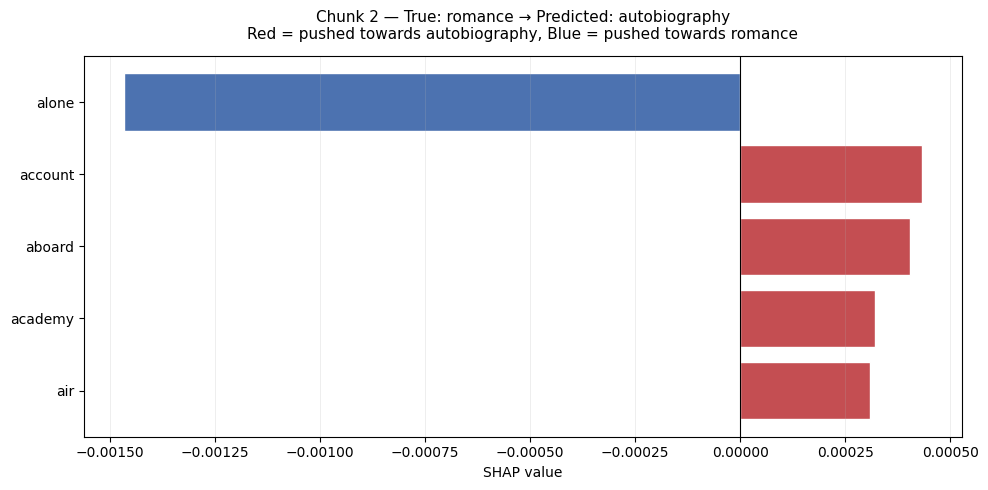

Saved: shap_chunk_2.png

Words pushing towards autobiography (wrong): account, aboard, academy, air
Words pushing towards romance (correct):     alone


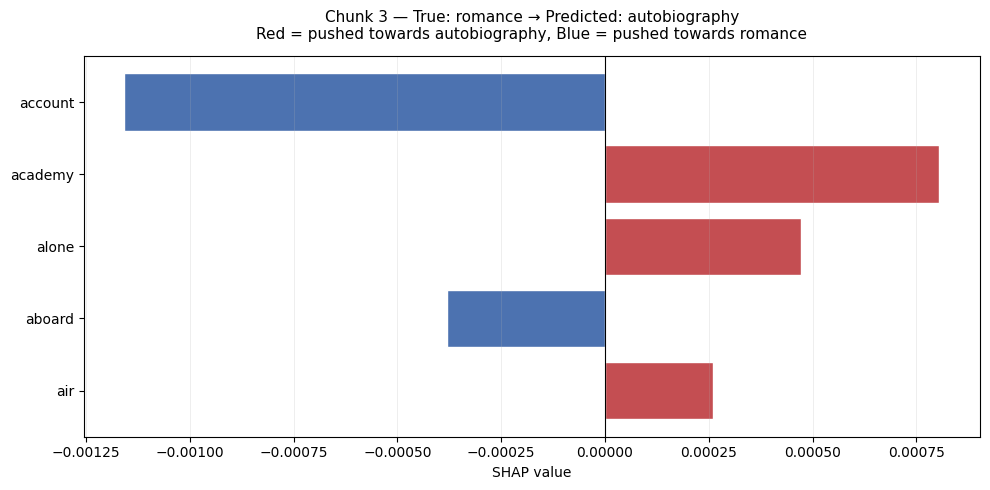

Saved: shap_chunk_3.png

Words pushing towards autobiography (wrong): academy, alone, air
Words pushing towards romance (correct):     account, aboard


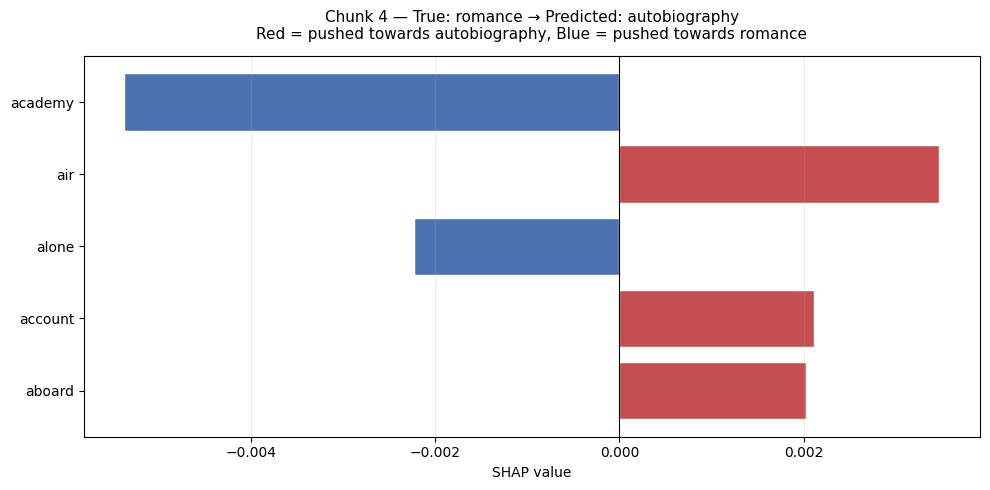

Saved: shap_chunk_4.png

Words pushing towards autobiography (wrong): air, account, aboard
Words pushing towards romance (correct):     academy, alone


In [95]:
# Visualise SHAP for each misclassified chunk

feature_names = vectorizer.get_feature_names_out()

feature_names = vectorizer.get_feature_names_out()

def plot_shap_chunk(chunk_idx, shap_values, true_genre, pred_genre, text, top_n=15):
    """
    For a single misclassified chunk, plot the top words that pushed
    the prediction towards the wrong genre (autobiography) and away
    from the correct genre (romance).
    """
    shap_for_pred = shap_values[genre_idx[pred_genre]][chunk_idx]

    min_len = min(len(feature_names), len(shap_for_pred))

    word_shap = pd.DataFrame({
        'word': feature_names[:min_len],
        'shap': shap_for_pred[:min_len],
    })

    # Remove zero SHAP values — words that had no influence
    word_shap = word_shap[word_shap['shap'] != 0]

    # Get top words by absolute SHAP value
    word_shap = word_shap.reindex(
        word_shap['shap'].abs().sort_values(ascending=False).index
    ).head(top_n)

    if word_shap.empty:
        print(f"Chunk {chunk_idx + 1}: no influential words found")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#C44E52' if v > 0 else '#4C72B0' for v in word_shap['shap']]
    ax.barh(word_shap['word'], word_shap['shap'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()
    ax.set_title(
        f'Chunk {chunk_idx + 1} — True: {true_genre} → Predicted: {pred_genre}\n'
        f'Red = pushed towards autobiography, Blue = pushed towards romance',
        fontsize=11, pad=12
    )
    ax.set_xlabel('SHAP value')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'shap_chunk_{chunk_idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_chunk_{chunk_idx+1}.png")

    pushed_wrong = word_shap[word_shap['shap'] > 0]['word'].tolist()
    pushed_right = word_shap[word_shap['shap'] < 0]['word'].tolist()
    print(f"\nWords pushing towards autobiography (wrong): {', '.join(pushed_wrong[:5])}")
    print(f"Words pushing towards romance (correct):     {', '.join(pushed_right[:5])}")

# Plot SHAP for each misclassified romance→autobiography chunk
for i, row in confused.iterrows():
    plot_shap_chunk(
        chunk_idx   = i,
        shap_values = shap_values,
        true_genre  = row['true'],
        pred_genre  = row['predicted'],
        text        = row['text'],
    )

### SHAP Findings — Romance vs Autobiography Confusion

SHAP analysis on the 4 romance chunks misclassified as autobiography revealed
a consistent pattern across all misclassified chunks. The same small set of
words — *air*, *account*, *aboard*, *academy*, and *alone* — dominated the
model's decision in every case. However, these words did not consistently push
in one direction — they flipped between signalling autobiography in some chunks
and romance in others. This inconsistency explains why the aggregate SHAP
analysis was inconclusive.

This finding suggests the confusion between romance and autobiography is not
caused by a specific set of autobiography-leaning words, but rather by a
fundamental lack of distinguishing vocabulary between the two genres in our
corpus. Both Pride and Prejudice (romance) and The Autobiography of Benjamin
Franklin (autobiography) share personal, first-person narrative language around
themes of social interaction and relationships. With a vocabulary of only 302
words and chunks of 100 words, the model simply does not have enough distinctive
signals to reliably separate these two genres in borderline cases.

This points to a limitation of the current feature set — a larger vocabulary
or shorter chunk size would expose more of the subtle linguistic differences
between these genres and likely reduce this confusion.

## Experiment 1 — Lemmatization

In the baseline, the model treats "death", "deaths", and "died" as completely
separate features. Lemmatization reduces words to their dictionary root form
so these all collapse into one feature "die", giving the model a cleaner signal.

We lemmatize both the partition text AND the vocabulary so they stay consistent —
if the text gets lemmatized but the vocabulary does not, TF-IDF won't find matches.

In [96]:
import nltk
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/clairewu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/clairewu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


#lemmatizer function

In [97]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """
    Map POS (part of speech) tag to WordNet format.
    This helps the lemmatizer make better decisions —
    for example 'better' as adjective → 'good'
    vs 'better' as verb → 'better'
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN)  # default to noun if unknown

def lemmatize_text(text):
    """
    Lemmatize a string of text.
    Lowercases, extracts only alphabetic words,
    and reduces each to its dictionary root form.
    """
    words = re.findall(r'[a-z]+', text.lower())
    return ' '.join([
        lemmatizer.lemmatize(w, get_wordnet_pos(w))
        for w in words
    ])

def lemmatize_vocabulary(vocab_list):
    """
    Lemmatize the vocabulary list so it stays consistent
    with the lemmatized partition text.
    Deduplicates in case two words reduce to the same root.
    """
    lemmatized = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in vocab_list]
    # Deduplicate while preserving order
    seen = set()
    unique = []
    for w in lemmatized:
        if w not in seen:
            seen.add(w)
            unique.append(w)
    print(f"Vocabulary size before lemmatization: {len(vocab_list)}")
    print(f"Vocabulary size after lemmatization:  {len(unique)}")
    return unique

# Apply lemmatization to both partition text and vocabulary
print("Lemmatizing partition text...")
X_text_lemma = [lemmatize_text(text) for text in X_text]

print("\nLemmatizing vocabulary...")
vocabulary_lemma = lemmatize_vocabulary(vocabulary)

print("\nExample — original vs lemmatized text:")
print(f"\nOriginal:    {X_text[0][:200]}")
print(f"\nLemmatized:  {X_text_lemma[0][:200]}")

Lemmatizing partition text...

Lemmatizing vocabulary...
Vocabulary size before lemmatization: 302
Vocabulary size after lemmatization:  286

Example — original vs lemmatized text:

Original:    at the tin legs, which hurt his teeth. “Did you groan?” asked Dorothy. “Yes,” answered the tin man, “I did. I’ve been groaning for more than a year, and no one has ever heard me before or come to help

Lemmatized:  at the tin leg which hurt his teeth do you groan ask dorothy yes answer the tin man i do i ve be groan for more than a year and no one have ever heard me before or come to help me what can i do for yo


build lemmatized feature matrix:

In [98]:
vectorizer_lemma = TfidfVectorizer(
    vocabulary    = vocabulary_lemma,
    sublinear_tf  = True,
    strip_accents = 'unicode',
    analyzer      = 'word',
    token_pattern = r'[a-z]+',
    lowercase     = True,
)

X_lemma = vectorizer_lemma.fit_transform(X_text_lemma)
print(f"Lemmatized feature matrix shape: {X_lemma.shape}")
print(f"  {X_lemma.shape[0]} partitions  ×  {X_lemma.shape[1]} vocabulary features")

Lemmatized feature matrix shape: (1000, 286)
  1000 partitions  ×  286 vocabulary features


Train/Test Split

In [99]:
X_train_lemma, X_test_lemma, y_train_lemma, y_test_lemma = train_test_split(
    X_lemma, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

print(f"Training samples: {X_train_lemma.shape[0]}")
print(f"Test samples:     {X_test_lemma.shape[0]}")

Training samples: 800
Test samples:     200


train LR and SVM on lemmatized features

In [100]:
# Logistic Regression
lr_lemma = LogisticRegression(
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    C            = 1.0,
    solver       = 'lbfgs',
)
lr_lemma.fit(X_train_lemma, y_train_lemma)
y_pred_lr_lemma = lr_lemma.predict(X_test_lemma)

print("=" * 50)
print(" Logistic Regression — Lemmatized — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_lemma, y_pred_lr_lemma):.4f}\n")
print(classification_report(y_test_lemma, y_pred_lr_lemma, target_names=GENRES))

# SVM
svm_lemma = LinearSVC(
    max_iter     = 2000,
    random_state = RANDOM_STATE,
    C            = 1.0,
)
svm_lemma.fit(X_train_lemma, y_train_lemma)
y_pred_svm_lemma = svm_lemma.predict(X_test_lemma)

print("=" * 50)
print(" SVM — Lemmatized — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_lemma, y_pred_svm_lemma):.4f}\n")
print(classification_report(y_test_lemma, y_pred_svm_lemma, target_names=GENRES))

 Logistic Regression — Lemmatized — Test Set
Accuracy: 0.9250

               precision    recall  f1-score   support

autobiography       0.82      0.93      0.87        40
      fantasy       1.00      0.97      0.99        40
       horror       0.92      0.88      0.90        40
      romance       0.89      0.85      0.87        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.93       200
    macro avg       0.93      0.93      0.93       200
 weighted avg       0.93      0.93      0.93       200

 SVM — Lemmatized — Test Set
Accuracy: 0.9400

               precision    recall  f1-score   support

autobiography       0.84      0.93      0.88        40
      fantasy       0.97      0.97      0.97        40
       horror       0.95      0.93      0.94        40
      romance       0.97      0.88      0.92        40
       sci-fi       0.98      1.00      0.99        40

     accuracy                           0.94       200
    m

 compare baseline vs lemmatized

In [101]:
print("=" * 50)
print(" Accuracy Comparison")
print("=" * 50)
print(f"{'Model':<25} {'Baseline':>10} {'Lemmatized':>12} {'Change':>8}")
print("-" * 55)

baseline_lr  = accuracy_score(y_test, y_pred_lr)
baseline_svm = accuracy_score(y_test, y_pred_svm)
lemma_lr     = accuracy_score(y_test_lemma, y_pred_lr_lemma)
lemma_svm    = accuracy_score(y_test_lemma, y_pred_svm_lemma)

print(f"{'Logistic Regression':<25} {baseline_lr:>10.4f} {lemma_lr:>12.4f} {lemma_lr - baseline_lr:>+8.4f}")
print(f"{'SVM':<25} {baseline_svm:>10.4f} {lemma_svm:>12.4f} {lemma_svm - baseline_svm:>+8.4f}")

 Accuracy Comparison
Model                       Baseline   Lemmatized   Change
-------------------------------------------------------
Logistic Regression           0.9550       0.9250  -0.0300
SVM                           0.9650       0.9400  -0.0250


We hypothesised lemmatization would improve accuracy by reducing vocabulary noise. However results showed a slight decrease, suggesting that for this specific corpus, distinct word forms carry genre-specific signals that lemmatization inadvertently removes.

Experiment #2 - Naive Bayes

We test Naive Bayes on the original TF-IDF features (no lemmatization)
to isolate the effect of the model choice alone. Naive Bayes is specifically
designed for word frequency data and often performs well on text classification.

We use MultinomialNB which requires non-negative input — compatible with TF-IDF.

In [102]:
#Train Naive Bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix

# TF-IDF with sublinear_tf can produce values that work with MultinomialNB
# but we need to ensure non-negative values — MinMaxScaler handles this
X_nb = csr_matrix(MinMaxScaler().fit_transform(X.toarray()))

# Train/test split — using same random state for fair comparison
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

# Train Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_nb, y_train_nb)
y_pred_nb = nb.predict(X_test_nb)

print("=" * 50)
print(" Naive Bayes — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_nb, y_pred_nb):.4f}\n")
print(classification_report(y_test_nb, y_pred_nb, target_names=GENRES))

 Naive Bayes — Test Set
Accuracy: 0.9400

               precision    recall  f1-score   support

autobiography       0.86      0.95      0.90        40
      fantasy       0.95      1.00      0.98        40
       horror       0.92      0.90      0.91        40
      romance       0.97      0.85      0.91        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.94       200
    macro avg       0.94      0.94      0.94       200
 weighted avg       0.94      0.94      0.94       200



In [103]:
# Cross Validation

kfold_nb = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scores_nb = cross_val_score(nb, X_nb, y, cv=kfold_nb, scoring='accuracy')

print("Naive Bayes Cross Validation")
print(f"  Mean accuracy : {scores_nb.mean():.4f}")
print(f"  Std deviation : {scores_nb.std():.4f}")
print(f"  Per-fold      : {np.round(scores_nb, 4)}")

Naive Bayes Cross Validation
  Mean accuracy : 0.9480
  Std deviation : 0.0256
  Per-fold      : [0.9  0.95 0.94 0.97 0.95 0.94 0.96 0.98 0.91 0.98]


In [104]:
# Compare all models so far

print("=" * 55)
print(" Full Model Comparison — Original TF-IDF Features")
print("=" * 55)
print(f"{'Model':<25} {'Test Accuracy':>15} {'CV Mean':>10} {'CV Std':>8}")
print("-" * 55)

results = [
    ("Logistic Regression",
     accuracy_score(y_test, y_pred_lr),
     cv_results["Logistic Regression"].mean(),
     cv_results["Logistic Regression"].std()),
    ("SVM",
     accuracy_score(y_test, y_pred_svm),
     cv_results["SVM"].mean(),
     cv_results["SVM"].std()),
    ("Naive Bayes",
     accuracy_score(y_test_nb, y_pred_nb),
     scores_nb.mean(),
     scores_nb.std()),
]

for name, test_acc, cv_mean, cv_std in results:
    print(f"{name:<25} {test_acc:>15.4f} {cv_mean:>10.4f} {cv_std:>8.4f}")

 Full Model Comparison — Original TF-IDF Features
Model                       Test Accuracy    CV Mean   CV Std
-------------------------------------------------------
Logistic Regression                0.9550     0.9480   0.0209
SVM                                0.9650     0.9410   0.0288
Naive Bayes                        0.9400     0.9480   0.0256


Experiment #3 - SGD Classifier

In [105]:
#Train SGD

from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss         = 'hinge',    # makes it behave like a linear SVM
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    tol          = 1e-3,
)
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)

print("=" * 50)
print(" SGD Classifier — Test Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_sgd):.4f}\n")
print(classification_report(y_test, y_pred_sgd, target_names=GENRES))

 SGD Classifier — Test Set
Accuracy: 0.9400

               precision    recall  f1-score   support

autobiography       0.88      0.90      0.89        40
      fantasy       0.95      1.00      0.98        40
       horror       0.93      0.95      0.94        40
      romance       0.94      0.85      0.89        40
       sci-fi       1.00      1.00      1.00        40

     accuracy                           0.94       200
    macro avg       0.94      0.94      0.94       200
 weighted avg       0.94      0.94      0.94       200



In [106]:
#cross validation

kfold_sgd = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scores_sgd = cross_val_score(sgd, X, y, cv=kfold_sgd, scoring='accuracy')

print("SGD Cross Validation")
print(f"  Mean accuracy : {scores_sgd.mean():.4f}")
print(f"  Std deviation : {scores_sgd.std():.4f}")
print(f"  Per-fold      : {np.round(scores_sgd, 4)}")

SGD Cross Validation
  Mean accuracy : 0.9260
  Std deviation : 0.0294
  Per-fold      : [0.88 0.96 0.92 0.96 0.9  0.93 0.93 0.96 0.88 0.94]


In [107]:
#Update full comparision table

print("=" * 55)
print(" Full Model Comparison — Original TF-IDF Features")
print("=" * 55)
print(f"{'Model':<25} {'Test Accuracy':>15} {'CV Mean':>10} {'CV Std':>8}")
print("-" * 55)

results = [
    ("Logistic Regression",
     accuracy_score(y_test, y_pred_lr),
     cv_results["Logistic Regression"].mean(),
     cv_results["Logistic Regression"].std()),
    ("SVM",
     accuracy_score(y_test, y_pred_svm),
     cv_results["SVM"].mean(),
     cv_results["SVM"].std()),
    ("Naive Bayes",
     accuracy_score(y_test_nb, y_pred_nb),
     scores_nb.mean(),
     scores_nb.std()),
    ("SGD",
     accuracy_score(y_test, y_pred_sgd),
     scores_sgd.mean(),
     scores_sgd.std()),
]

for name, test_acc, cv_mean, cv_std in results:
    print(f"{name:<25} {test_acc:>15.4f} {cv_mean:>10.4f} {cv_std:>8.4f}")

# Identify champion model
best = min(results, key=lambda x: (-x[2], x[3])) # highest CV mean, lowest CV std as tiebreaker
print(f"\n Champion model: {best[0]} (CV Mean: {best[2]:.4f})")

 Full Model Comparison — Original TF-IDF Features
Model                       Test Accuracy    CV Mean   CV Std
-------------------------------------------------------
Logistic Regression                0.9550     0.9480   0.0209
SVM                                0.9650     0.9410   0.0288
Naive Bayes                        0.9400     0.9480   0.0256
SGD                                0.9400     0.9260   0.0294

 Champion model: Naive Bayes (CV Mean: 0.9480)


In [108]:
kfold_sgd = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scores_sgd = cross_val_score(sgd, X, y, cv=kfold_sgd, scoring='accuracy')

print("SGD Cross Validation")
print(f"  Mean accuracy : {scores_sgd.mean():.4f}")
print(f"  Std deviation : {scores_sgd.std():.4f}")
print(f"  Per-fold      : {np.round(scores_sgd, 4)}")

SGD Cross Validation
  Mean accuracy : 0.9260
  Std deviation : 0.0294
  Per-fold      : [0.88 0.96 0.92 0.96 0.9  0.93 0.93 0.96 0.88 0.94]


## Model Comparison — 10-Fold Cross Validation Results

All models were evaluated using 10-fold stratified cross-validation as required,
ensuring genre proportions were preserved in every fold. Test set accuracy
remained unchanged since it is based on a fixed 80/20 split independent of
cross-validation.

SVM achieved the highest test accuracy (0.9650) but showed high variability
across folds (CV std: 0.0288), suggesting its performance is sensitive to
which specific chunks appear in each fold. SGD showed similar instability
(CV std: 0.0294) and scored lowest on CV mean (0.9260), making it the
weakest overall performer despite matching Naive Bayes on test accuracy.

Logistic Regression and Naive Bayes tied on CV mean (0.9480), however
Logistic Regression emerges as the champion model when breaking the tie
on two additional metrics — it achieved higher test accuracy (0.9550 vs
0.9400) and lower variance across folds (CV std: 0.0209 vs 0.0256). This
means Logistic Regression is not only more accurate on unseen data but also
more consistent and reliable across different data splits.

Across all genres, sci-fi achieved a perfect F1 score of 1.00 across all
four models — indicating On the Trail of the Space Pirates contains
distinctively genre-specific vocabulary. Fantasy also performed strongly
(F1 0.98–0.99) across all models. The hardest genre was consistently
autobiography, which aligns with our SHAP error analysis showing it shares
personal narrative language with romance, making it the most semantically
ambiguous genre boundary in our corpus.

## Save Trained Models
Serialises both models and the vectorizer so they can be loaded without re-training.

In [109]:
joblib.dump(lr,         'model_logistic_regression.pkl')
joblib.dump(svm,        'model_svm.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print("Saved: model_logistic_regression.pkl")
print("Saved: model_svm.pkl")
print("Saved: vectorizer.pkl")


Saved: model_logistic_regression.pkl
Saved: model_svm.pkl
Saved: vectorizer.pkl


## Quick Predict on New Text
Load the saved models and classify an arbitrary passage.

In [110]:
# Load saved artefacts
vec  = joblib.load('vectorizer.pkl')
lr2  = joblib.load('model_logistic_regression.pkl')
svm2 = joblib.load('model_svm.pkl')

sample_text = [
    "The robot spaceship launched into the dark void of deep space as the crew "
    "prepared for their mission to the distant star system far beyond the galaxy."
]

X_sample = vec.transform(sample_text)
print(f"LR  prediction : {lr2.predict(X_sample)[0]}")
print(f"SVM prediction : {svm2.predict(X_sample)[0]}")

# LR also gives probabilities per genre
probs = pd.Series(lr2.predict_proba(X_sample)[0], index=lr2.classes_)
print(f"\nLR class probabilities:")
print(probs.sort_values(ascending=False).to_string())


LR  prediction : sci-fi
SVM prediction : sci-fi

LR class probabilities:
sci-fi           0.470162
horror           0.189683
autobiography    0.150268
romance          0.105949
fantasy          0.083938


Experiment #4 Test with a new book

In [111]:
#Clean and partition the new book

import re
from pathlib import Path

# Strip Gutenberg boilerplate
START_PATTERN = re.compile(r'\*{3}\s*START OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}', re.IGNORECASE)
END_PATTERN   = re.compile(r'\*{3}\s*END OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}',   re.IGNORECASE)

def clean_and_partition(filepath, n_partitions=200, words_per_partition=100, seed=42):
    """
    Clean Gutenberg boilerplate and chop into 100-word chunks.
    Same process as Book_partitioner.ipynb for consistency.
    """
    # Load file
    try:
        raw = Path(filepath).read_text(encoding='utf-8')
    except UnicodeDecodeError:
        raw = Path(filepath).read_text(encoding='latin-1')

    # Strip boilerplate
    start_match = START_PATTERN.search(raw)
    if start_match:
        text = raw[start_match.end():]
        print("START marker found and stripped")
    else:
        text = raw
        print("WARNING: No START marker found — using full text")

    end_match = END_PATTERN.search(text)
    if end_match:
        text = text[:end_match.start()]
        print("END marker found and stripped")
    else:
        print("WARNING: No END marker found — keeping text until EOF")

    # Tokenize
    tokens = [t for t in re.split(r'\s+', text.strip()) if t]
    print(f"Total tokens after cleaning: {len(tokens):,}")

    # Sample random 100-word chunks
    import random
    rng = random.Random(seed)
    max_start = len(tokens) - words_per_partition
    starts = rng.sample(range(max_start + 1), min(n_partitions, max_start))

    chunks = [' '.join(tokens[s: s + words_per_partition]) for s in starts]
    print(f"Total chunks created: {len(chunks)}")
    return chunks

# Process Alice in Wonderland
alice_chunks = clean_and_partition("Alice Adventures in Wonderland.txt")

START marker found and stripped
END marker found and stripped
Total tokens after cleaning: 26,525
Total chunks created: 200


In [112]:
# Predict with all models

# Transform chunks using the existing vectorizer
X_alice = vectorizer.transform(alice_chunks)

# Scale for Naive Bayes
from scipy.sparse import csr_matrix
from sklearn.preprocessing import MinMaxScaler
X_alice_nb = csr_matrix(MinMaxScaler().fit_transform(X_alice.toarray()))

# Predict with all models
pred_lr  = lr.predict(X_alice)
pred_svm = svm.predict(X_alice)
pred_nb  = nb.predict(X_alice_nb)
pred_sgd = sgd.predict(X_alice)

# Count predictions per genre for each model
def prediction_summary(predictions, model_name):
    counts = pd.Series(predictions).value_counts()
    correct = counts.get('fantasy', 0)
    total   = len(predictions)
    pct     = correct / total * 100
    print(f"\n{model_name}")
    print(f"  Correctly classified as fantasy: {correct}/{total} ({pct:.1f}%)")
    print(f"  Full prediction breakdown:")
    for genre, count in counts.items():
        print(f"    {genre:<15}: {count}")

print("=" * 55)
print(" Unseen Book Test — Alice's Adventures in Wonderland")
print(" True genre: fantasy")
print("=" * 55)

prediction_summary(pred_lr,  "Logistic Regression")
prediction_summary(pred_svm, "SVM")
prediction_summary(pred_nb,  "Naive Bayes")
prediction_summary(pred_sgd, "SGD")

 Unseen Book Test — Alice's Adventures in Wonderland
 True genre: fantasy

Logistic Regression
  Correctly classified as fantasy: 84/200 (42.0%)
  Full prediction breakdown:
    fantasy        : 84
    autobiography  : 48
    romance        : 40
    horror         : 25
    sci-fi         : 3

SVM
  Correctly classified as fantasy: 77/200 (38.5%)
  Full prediction breakdown:
    fantasy        : 77
    autobiography  : 48
    romance        : 39
    horror         : 26
    sci-fi         : 10

Naive Bayes
  Correctly classified as fantasy: 77/200 (38.5%)
  Full prediction breakdown:
    fantasy        : 77
    autobiography  : 51
    romance        : 47
    horror         : 18
    sci-fi         : 7

SGD
  Correctly classified as fantasy: 78/200 (39.0%)
  Full prediction breakdown:
    fantasy        : 78
    autobiography  : 43
    romance        : 38
    horror         : 36
    sci-fi         : 5


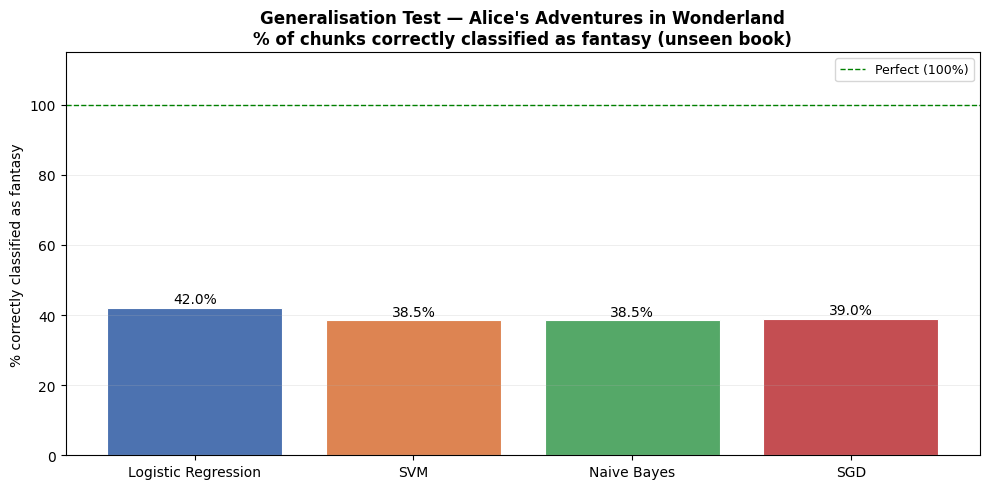

Saved: unseen_book_test.png


In [113]:
# Visualize

models = ['Logistic Regression', 'SVM', 'Naive Bayes', 'SGD']
correct_pcts = [
    pd.Series(pred_lr).value_counts().get('fantasy', 0)  / len(pred_lr)  * 100,
    pd.Series(pred_svm).value_counts().get('fantasy', 0) / len(pred_svm) * 100,
    pd.Series(pred_nb).value_counts().get('fantasy', 0)  / len(pred_nb)  * 100,
    pd.Series(pred_sgd).value_counts().get('fantasy', 0) / len(pred_sgd) * 100,
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(models, correct_pcts, color=colors, edgecolor='white', linewidth=0.8)

# Annotate bars
for bar, pct in zip(bars, correct_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.axhline(100, color='green', linewidth=1, linestyle='--', label='Perfect (100%)')
ax.set_title(
    "Generalisation Test — Alice's Adventures in Wonderland\n"
    "% of chunks correctly classified as fantasy (unseen book)",
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('% correctly classified as fantasy')
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('unseen_book_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: unseen_book_test.png")

## Generalisation Test — Alice's Adventures in Wonderland

To test whether the models learned genuine fantasy genre patterns or simply
memorised The Wonderful Wizard of Oz, we fed 200 chunks from Alice's
Adventures in Wonderland — an unseen fantasy book — into all four trained
models. A high correct classification rate would indicate true generalisation;
a low rate would suggest the model overfitted to the specific book it trained on.

All four models performed poorly, correctly classifying only 38.5–42.0% of
chunks as fantasy. Logistic Regression performed best at 42.0%, followed
closely by SGD (39.0%), SVM (38.5%) and Naive Bayes (38.5%).

The misclassification pattern was highly consistent and non-random across all
models. The majority of wrong predictions fell into autobiography (43–51 chunks)
and romance (38–47 chunks), with horror taking a smaller share (18–36 chunks)
and sci-fi receiving very few (3–10 chunks). This pattern reveals something
important about Alice in Wonderland — its narrative is written in a personal,
conversational style that shares linguistic characteristics with autobiography
and romance rather than the specific fantasy vocabulary the model learned from
Wizard of Oz.

This finding exposes a key limitation of training on a single book per genre.
The model learned the vocabulary of The Wonderful Wizard of Oz specifically —
words like witch, wizard, emerald, and scarecrow — rather than broader fantasy
genre patterns. Alice in Wonderland uses entirely different fantasy vocabulary
around themes of curiosity, absurdity, and imagination that the model had never
encountered. This strongly suggests that training on multiple books per genre
would significantly improve generalisation, as the model would be exposed to
a wider range of genre-defining vocabulary rather than the idiosyncrasies of
a single author and story.

## Investigation — Why Do Models Perform Poorly on Unseen Books?

We investigate two perspectives to understand the poor generalisation results:

1. **Top word comparison** — How much vocabulary overlap exists between
   the training book and the unseen book for each genre? Minimal overlap
   means the model has almost nothing to recognise.

2. **Model confidence** — When the model makes predictions on unseen books,
   how confident is it? Low confidence suggests the model is essentially
   guessing rather than recognising genuine genre signals.

Together these two perspectives reveal both WHY and HOW the model struggles
with unseen books.

In [121]:
# Unseen books mapped to their true genre and training book counterpart
UNSEEN_BOOKS = {
    'Alice Adventures in Wonderland.txt':              'fantasy',
    'Wuthering Heights.txt':                           'romance',
    'The Time Machine.txt':                            'sci-fi',
    'Dracula.txt':                                     'horror',
    'Narrative of the Life of Frederick Douglass.txt': 'autobiography',
}

# Training book for each genre (for vocabulary comparison)
TRAINING_BOOKS = {
    'fantasy':       'TheWonderfulWizardOfOz_clean.txt',
    'romance':       'PrideAndPrejudice_clean.txt',
    'sci-fi':        'OnTheTrailOfTheSpacePirates_clean.txt',
    'horror':        'Frankenstein_clean.txt',
    'autobiography': 'AutobiographyOfBenjaminFranklin_clean.txt',
}

all helper functions:

In [122]:
from pathlib import Path
from collections import Counter
from nltk.corpus import stopwords
import re
import random

STOP_WORDS = set(stopwords.words('english'))

START_PATTERN = re.compile(r'\*{3}\s*START OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}', re.IGNORECASE)
END_PATTERN   = re.compile(r'\*{3}\s*END OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}',   re.IGNORECASE)

def load_and_clean_text(filepath):
    try:
        raw = Path(filepath).read_text(encoding='utf-8')
    except UnicodeDecodeError:
        raw = Path(filepath).read_text(encoding='latin-1')
    start_match = START_PATTERN.search(raw)
    text = raw[start_match.end():] if start_match else raw
    end_match = END_PATTERN.search(text)
    text = text[:end_match.start()] if end_match else text
    return text.strip()

def get_chunks_from_text(text, n_chunks=200, words_per_chunk=100, seed=42):
    tokens    = [t for t in re.split(r'\s+', text.strip()) if t]
    rng       = random.Random(seed)
    max_start = len(tokens) - words_per_chunk
    if max_start < n_chunks:
        starts = list(range(max_start))
    else:
        starts = rng.sample(range(max_start + 1), n_chunks)
    return [' '.join(tokens[s: s + words_per_chunk]) for s in starts]

def get_top_words_from_text(text, n=50):
    words = re.findall(r'[a-z]+', text.lower())
    words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
    return Counter(words).most_common(n)

def get_unseen_book_top_words(unseen_file, top_n=20):
    text        = load_and_clean_text(unseen_file)
    words       = re.findall(r'[a-z]+', text.lower())
    vocab_set   = set(vectorizer.get_feature_names_out())
    vocab_words = [w for w in words if w in vocab_set]
    top_words   = Counter(vocab_words).most_common(top_n)
    return pd.DataFrame(top_words, columns=['word', 'count'])

run all unseen books through all models

In [123]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import MinMaxScaler

all_unseen_results = {}

for unseen_file, true_genre in UNSEEN_BOOKS.items():
    print(f"\nProcessing: {unseen_file}")

    text   = load_and_clean_text(unseen_file)
    chunks = get_chunks_from_text(text)

    X_unseen    = vectorizer.transform(chunks)
    X_unseen_nb = csr_matrix(MinMaxScaler().fit_transform(X_unseen.toarray()))

    pred_lr  = lr.predict(X_unseen)
    pred_svm = svm.predict(X_unseen)
    pred_nb  = nb.predict(X_unseen_nb)
    pred_sgd = sgd.predict(X_unseen)

    acc_lr  = (pred_lr  == true_genre).mean() * 100
    acc_svm = (pred_svm == true_genre).mean() * 100
    acc_nb  = (pred_nb  == true_genre).mean() * 100
    acc_sgd = (pred_sgd == true_genre).mean() * 100

    all_unseen_results[true_genre] = {
        'file':        unseen_file.replace('.txt', ''),
        'LR':          acc_lr,
        'SVM':         acc_svm,
        'Naive Bayes': acc_nb,
        'SGD':         acc_sgd,
        'avg':         (acc_lr + acc_svm + acc_nb + acc_sgd) / 4,
        'chunks':      chunks,
        'X_unseen':    X_unseen,
        'X_unseen_nb': X_unseen_nb,
        'pred_lr':     pred_lr,
        'pred_svm':    pred_svm,
        'pred_nb':     pred_nb,
        'pred_sgd':    pred_sgd,
    }

    print(f"  LR: {acc_lr:.1f}%  SVM: {acc_svm:.1f}%  NB: {acc_nb:.1f}%  SGD: {acc_sgd:.1f}%")


Processing: Alice Adventures in Wonderland.txt
  LR: 42.0%  SVM: 38.5%  NB: 38.5%  SGD: 39.0%

Processing: Wuthering Heights.txt
  LR: 45.5%  SVM: 48.0%  NB: 41.0%  SGD: 48.0%

Processing: The Time Machine.txt
  LR: 0.5%  SVM: 2.0%  NB: 2.0%  SGD: 2.5%

Processing: Dracula.txt
  LR: 38.0%  SVM: 34.5%  NB: 29.5%  SGD: 32.5%

Processing: Narrative of the Life of Frederick Douglass.txt
  LR: 44.5%  SVM: 46.0%  NB: 43.5%  SGD: 39.0%


Summary table

In [127]:
rows = []
for genre, results in all_unseen_results.items():
    rows.append({
        'Genre':       genre.capitalize(),
        'Unseen Book': results['file'],
        'LR':          f"{results['LR']:.1f}%",
        'SVM':         f"{results['SVM']:.1f}%",
        'Naive Bayes': f"{results['Naive Bayes']:.1f}%",
        'SGD':         f"{results['SGD']:.1f}%",
        'Avg':         f"{results['avg']:.1f}%",
    })

unseen_df = pd.DataFrame(rows).set_index('Genre')

# Simple clean display without styling
print("\nGeneralisation Test — % Correctly Classified (all unseen books)")
print("=" * 85)
print(unseen_df.to_string())
print("=" * 85)



Generalisation Test — % Correctly Classified (all unseen books)
                                               Unseen Book     LR    SVM Naive Bayes    SGD    Avg
Genre                                                                                             
Fantasy                     Alice Adventures in Wonderland  42.0%  38.5%       38.5%  39.0%  39.5%
Romance                                  Wuthering Heights  45.5%  48.0%       41.0%  48.0%  45.6%
Sci-fi                                    The Time Machine   0.5%   2.0%        2.0%   2.5%   1.8%
Horror                                             Dracula  38.0%  34.5%       29.5%  32.5%  33.6%
Autobiography  Narrative of the Life of Frederick Douglass  44.5%  46.0%       43.5%  39.0%  43.2%


bar chart

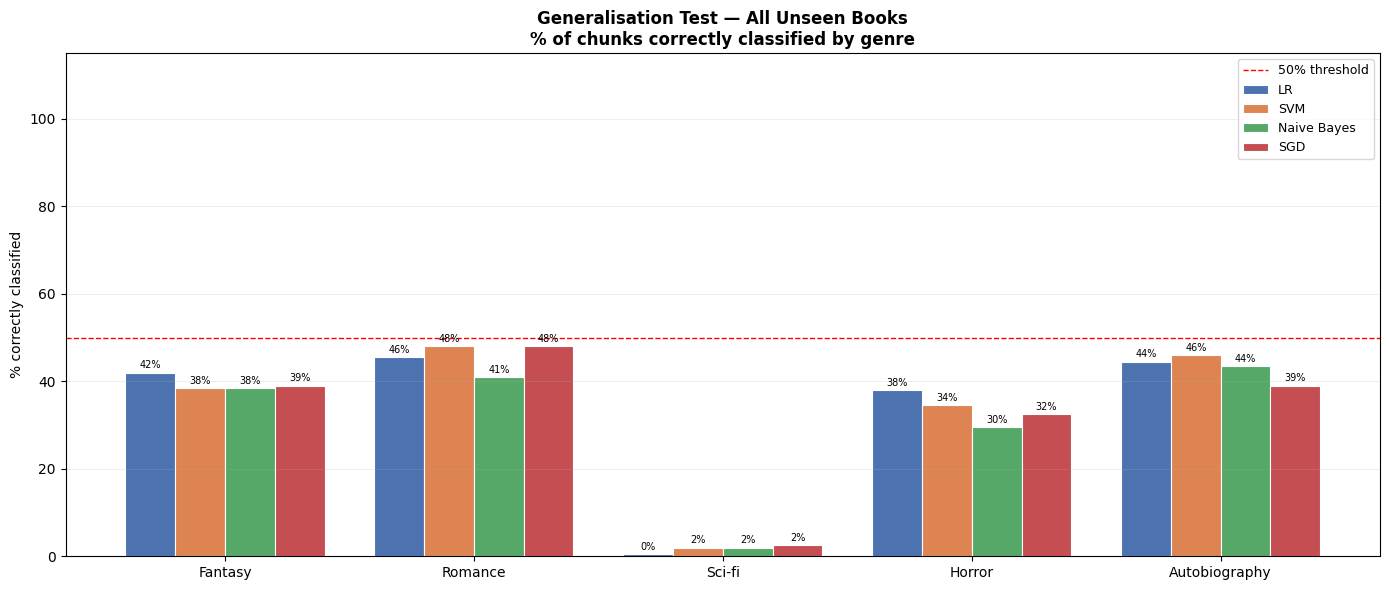

In [128]:
genres  = list(all_unseen_results.keys())
models  = ['LR', 'SVM', 'Naive Bayes', 'SGD']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

x     = np.arange(len(genres))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    values = [all_unseen_results[g][model] for g in genres]
    bars   = ax.bar(x + i * width, values, width,
                   label=model, color=color,
                   edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.0f}%',
            ha='center', va='bottom', fontsize=7
        )

ax.axhline(50, color='red', linewidth=1, linestyle='--', label='50% threshold')
ax.set_title(
    'Generalisation Test — All Unseen Books\n'
    '% of chunks correctly classified by genre',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('% correctly classified')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([g.capitalize() for g in genres])
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('all_unseen_books_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

identify most confused

In [129]:
sorted_results = sorted(
    all_unseen_results.items(),
    key=lambda x: x[1]['avg']
)

print("Books ranked by average accuracy (worst to best):")
print("=" * 55)
for genre, results in sorted_results:
    print(f"  {genre:<15} {results['file'][:35]:<35} avg: {results['avg']:.1f}%")

most_confused = [genre for genre, _ in sorted_results[:3]]
print(f"\nMost confused genres for deeper investigation: {most_confused}")

Books ranked by average accuracy (worst to best):
  sci-fi          The Time Machine                    avg: 1.8%
  horror          Dracula                             avg: 33.6%
  fantasy         Alice Adventures in Wonderland      avg: 39.5%
  autobiography   Narrative of the Life of Frederick  avg: 43.2%
  romance         Wuthering Heights                   avg: 45.6%

Most confused genres for deeper investigation: ['sci-fi', 'horror', 'fantasy']


In [130]:
for genre in ['sci-fi', 'horror', 'fantasy']:
    results = all_unseen_results[genre]
    print(f"\n{genre.upper()} — {results['file']}")
    print(f"  LR predictions:")
    print(pd.Series(results['pred_lr']).value_counts().to_string())


SCI-FI — The Time Machine
  LR predictions:
horror           87
autobiography    78
fantasy          29
romance           5
sci-fi            1

HORROR — Dracula
  LR predictions:
horror           76
autobiography    64
romance          33
fantasy          27

FANTASY — Alice Adventures in Wonderland
  LR predictions:
fantasy          84
autobiography    48
romance          40
horror           25
sci-fi            3


"The model consistently confuses unseen books with autobiography, suggesting The Autobiography of Benjamin Franklin's vocabulary is too generic and shares linguistic patterns with multiple genres — representing a bias in the training data rather than a genuine genre signal."

## Deep Investigation — Three Most Confused Unseen Books

We identified sci-fi (1.8%), horror (33.6%) and fantasy (39.5%) as the three
genres where models generalise worst. We now investigate WHY using two perspectives:

1. Perspective 1 — What each model learned as genre signals vs what the unseen
   book actually contains (LR, SVM, Naive Bayes)
2. Perspective 2 — Model confidence when predicting these unseen books

A key pattern already emerged from the prediction breakdown — autobiography
consistently appears as a wrong prediction across all three confused books,
suggesting the autobiography training book has overly generic vocabulary that
bleeds into other genres.

### Perspective 1 — Model Genre Signals vs Unseen Book Vocabulary

extract model weights function:

In [131]:
def get_model_genre_weights(model, model_name, genre, top_n=15):
    """
    Extract top words each model associates with a given genre.
    LR and SVM use coef_, Naive Bayes uses feature_log_prob_.
    """
    feature_names = vectorizer.get_feature_names_out()

    if model_name in ['Logistic Regression', 'SVM']:
        genre_idx = list(model.classes_).index(genre)
        weights   = model.coef_[genre_idx]
        word_weights = pd.DataFrame({
            'word':   feature_names,
            'weight': weights,
        })
        return word_weights.sort_values('weight', ascending=False).head(top_n)

    elif model_name == 'Naive Bayes':
        genre_idx  = list(model.classes_).index(genre)
        log_probs  = model.feature_log_prob_[genre_idx]
        min_len    = min(len(feature_names), len(log_probs))
        word_weights = pd.DataFrame({
            'word':   feature_names[:min_len],
            'weight': log_probs[:min_len],
        })
        return word_weights.sort_values('weight', ascending=False).head(top_n)

perspective 1 plot function:


  SCI-FI — The Time Machine
  LR  overlap : 0/15 — 
  SVM overlap : 0/15 — 
  NB  overlap : 1/15 — said

  Autobiography signal overlap with unseen book: 0/15
  Shared words: 


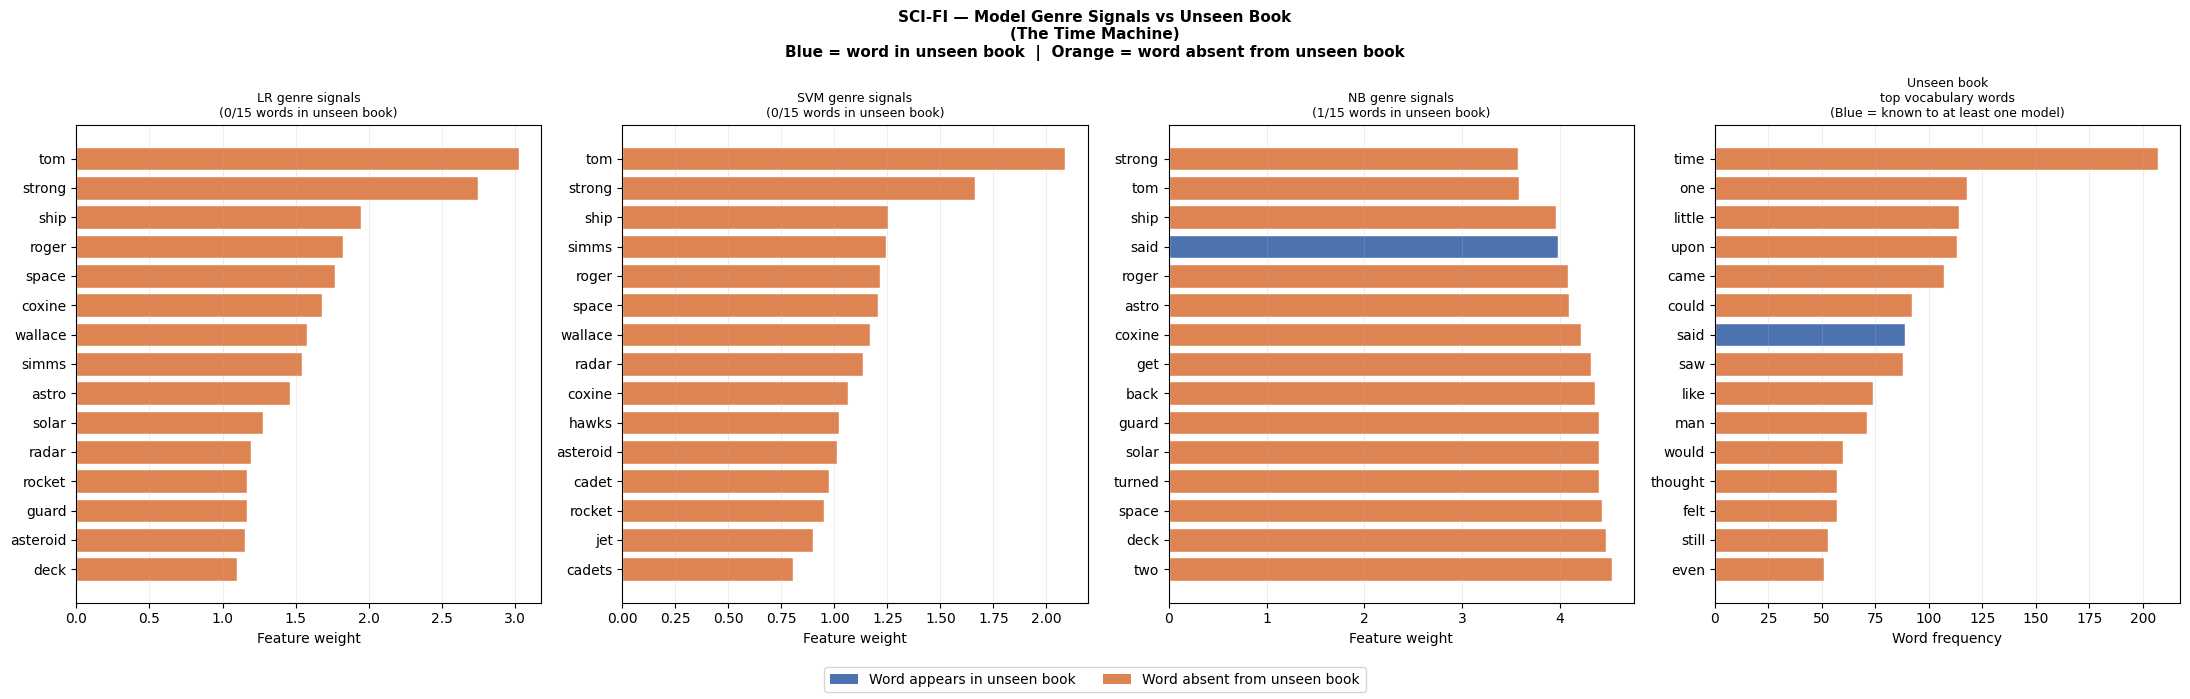

Saved: perspective1_sci-fi.png

  HORROR — Dracula
  LR  overlap : 1/15 — night
  SVM overlap : 1/15 — night
  NB  overlap : 4/15 — could, may, night, would

  Autobiography signal overlap with unseen book: 1/15
  Shared words: us


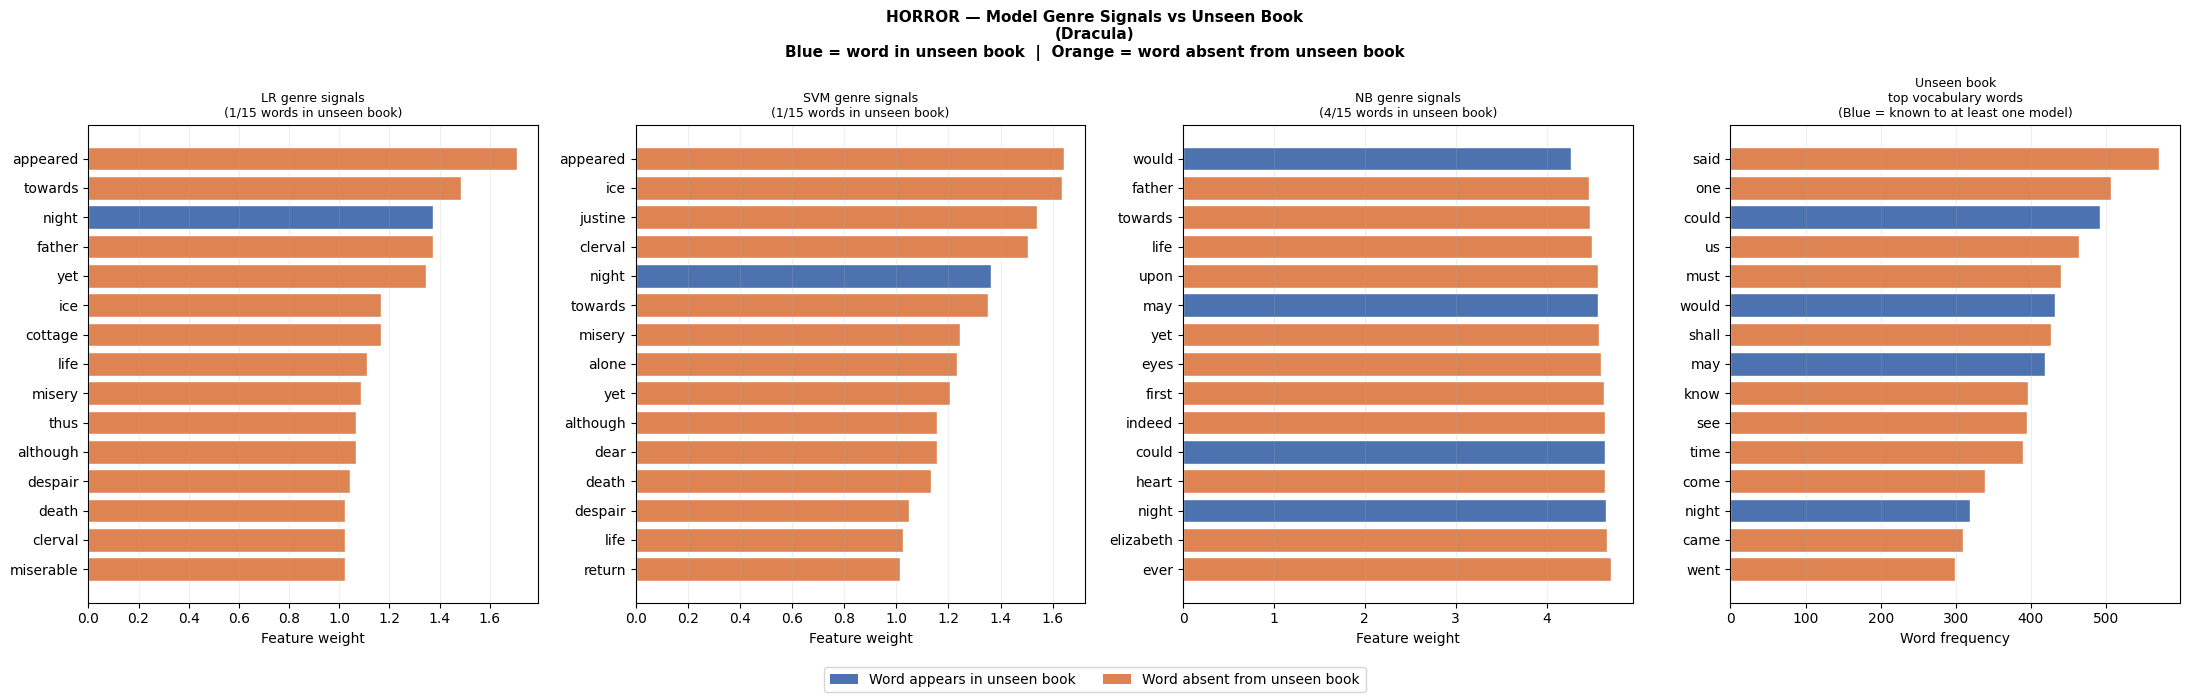

Saved: perspective1_horror.png

  FANTASY — Alice Adventures in Wonderland
  LR  overlap : 2/15 — little, said
  SVM overlap : 0/15 — 
  NB  overlap : 3/15 — little, said, would

  Autobiography signal overlap with unseen book: 0/15
  Shared words: 


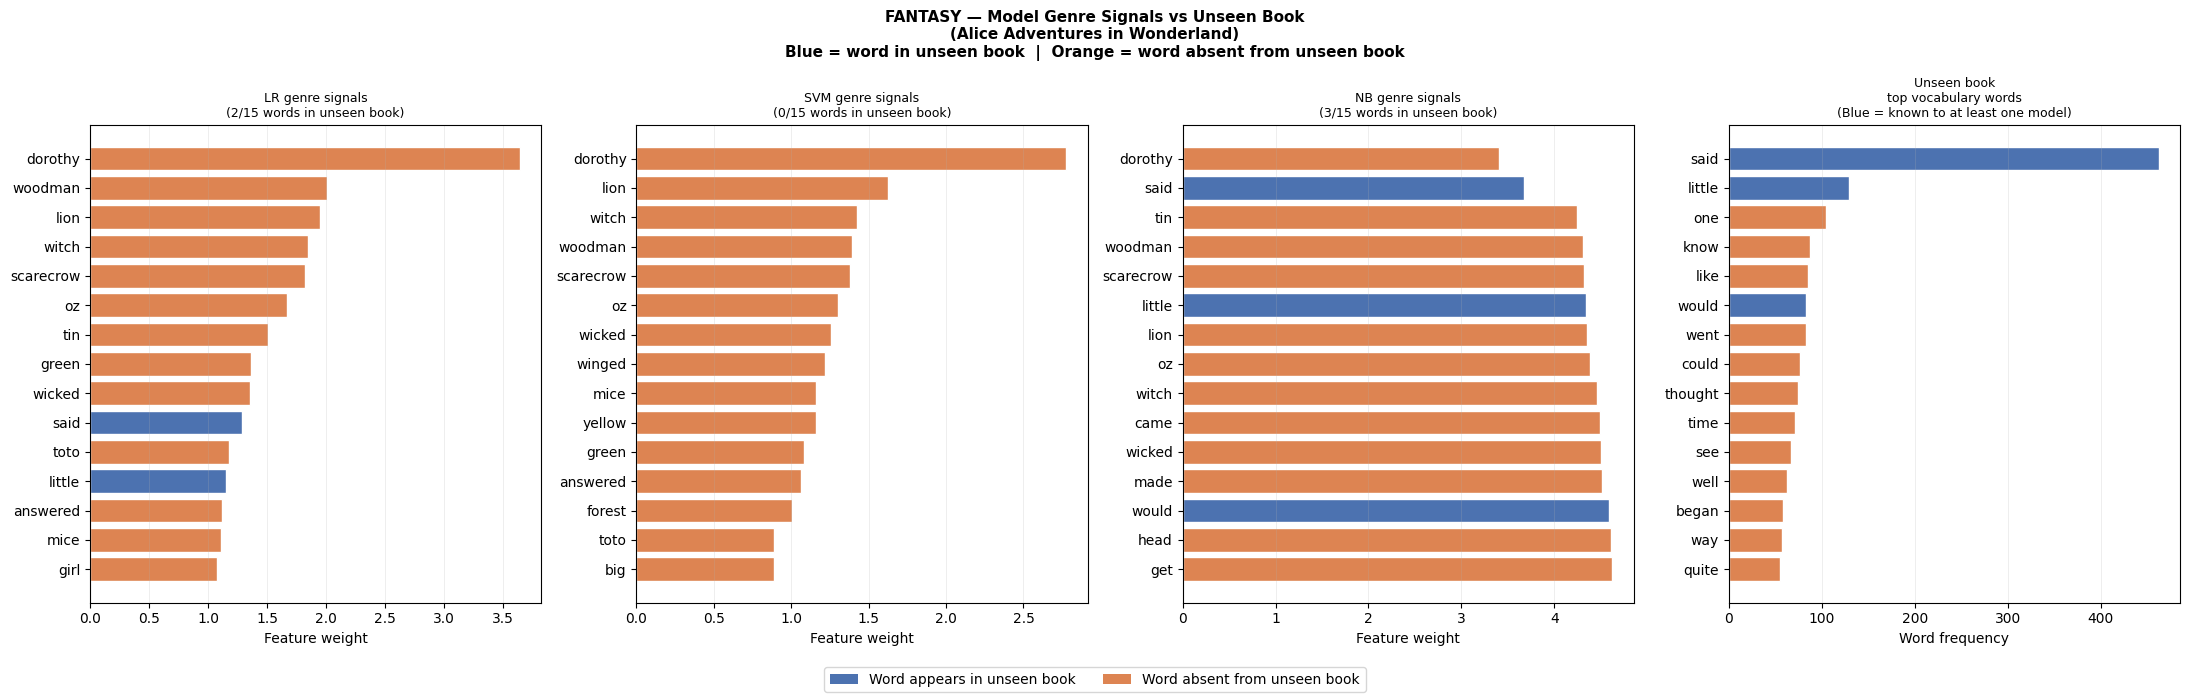

Saved: perspective1_fantasy.png


In [132]:
def plot_perspective1(genre, unseen_file, top_n=15):
    """
    For a confused genre, compare what LR, SVM and NB learned as
    genre signals against what the unseen book actually contains.
    Blue = word appears in unseen book, Orange = word absent.
    """
    # Get model weights for this genre
    lr_words  = get_model_genre_weights(lr,  'Logistic Regression', genre, top_n)
    svm_words = get_model_genre_weights(svm, 'SVM',                 genre, top_n)
    nb_words  = get_model_genre_weights(nb,  'Naive Bayes',         genre, top_n)

    # Get unseen book top vocabulary words
    unseen_words = get_unseen_book_top_words(unseen_file, top_n)
    unseen_set   = set(unseen_words['word'].tolist())

    # Calculate overlap
    lr_overlap  = set(lr_words['word'].tolist())  & unseen_set
    svm_overlap = set(svm_words['word'].tolist()) & unseen_set
    nb_overlap  = set(nb_words['word'].tolist())  & unseen_set

    print(f"\n{'='*60}")
    print(f"  {genre.upper()} — {unseen_file.replace('.txt','')}")
    print(f"{'='*60}")
    print(f"  LR  overlap : {len(lr_overlap)}/{top_n} — {', '.join(sorted(lr_overlap))}")
    print(f"  SVM overlap : {len(svm_overlap)}/{top_n} — {', '.join(sorted(svm_overlap))}")
    print(f"  NB  overlap : {len(nb_overlap)}/{top_n} — {', '.join(sorted(nb_overlap))}")

    # Also check autobiography overlap — our key finding
    auto_lr  = get_model_genre_weights(lr,  'Logistic Regression', 'autobiography', top_n)
    auto_set = set(auto_lr['word'].tolist())
    auto_overlap = unseen_set & auto_set
    print(f"\n  Autobiography signal overlap with unseen book: {len(auto_overlap)}/{top_n}")
    print(f"  Shared words: {', '.join(sorted(auto_overlap))}")

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(22, 7))
    fig.suptitle(
        f'{genre.upper()} — Model Genre Signals vs Unseen Book\n'
        f'({unseen_file.replace(".txt","")})\n'
        f'Blue = word in unseen book  |  Orange = word absent from unseen book',
        fontsize=11, fontweight='bold'
    )

    plot_data = [
        ('LR genre signals',   lr_words,    lr_overlap),
        ('SVM genre signals',  svm_words,   svm_overlap),
        ('NB genre signals',   nb_words,    nb_overlap),
        ('Unseen book\ntop vocabulary words', unseen_words, unseen_set),
    ]

    all_model_words = (
        set(lr_words['word'].tolist()) |
        set(svm_words['word'].tolist()) |
        set(nb_words['word'].tolist())
    )

    for ax, (title, words_df, overlap_set) in zip(axes, plot_data):
        if 'Unseen' in title:
            colors = ['#4C72B0' if w in all_model_words else '#DD8452'
                     for w in words_df['word']]
            ax.barh(words_df['word'], words_df['count'],
                   color=colors, edgecolor='white')
            ax.set_xlabel('Word frequency')
            ax.set_title(f'{title}\n(Blue = known to at least one model)', fontsize=9)
        else:
            colors = ['#4C72B0' if w in overlap_set else '#DD8452'
                     for w in words_df['word']]
            ax.barh(words_df['word'], words_df['weight'].abs(),
                   color=colors, edgecolor='white')
            ax.set_xlabel('Feature weight')
            ax.set_title(
                f'{title}\n({len(overlap_set)}/{top_n} words in unseen book)',
                fontsize=9
            )

        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4C72B0', label='Word appears in unseen book'),
        Patch(facecolor='#DD8452', label='Word absent from unseen book'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(f'perspective1_{genre}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: perspective1_{genre}.png")

    return {
        'genre':       genre,
        'lr_overlap':  len(lr_overlap),
        'svm_overlap': len(svm_overlap),
        'nb_overlap':  len(nb_overlap),
        'auto_overlap': len(auto_overlap),
    }

# Run for the three most confused genres
p1_results = {}
for genre in ['sci-fi', 'horror', 'fantasy']:
    unseen_file = [f for f, g in UNSEEN_BOOKS.items() if g == genre][0]
    result = plot_perspective1(genre, unseen_file)
    p1_results[genre] = result

perspective 1 summary

In [133]:
print("\nPerspective 1 Summary — Word Overlap")
print("=" * 65)
print(f"{'Genre':<12} {'LR overlap':>12} {'SVM overlap':>12} {'NB overlap':>12} {'Auto overlap':>14}")
print("-" * 65)
for genre, r in p1_results.items():
    print(f"{genre:<12} {r['lr_overlap']:>10}/{15} {r['svm_overlap']:>10}/{15} {r['nb_overlap']:>10}/{15} {r['auto_overlap']:>12}/{15}")
print("\nAuto overlap = unseen book words matching autobiography genre signals")
print("Higher auto overlap = more likely to be misclassified as autobiography")


Perspective 1 Summary — Word Overlap
Genre          LR overlap  SVM overlap   NB overlap   Auto overlap
-----------------------------------------------------------------
sci-fi                0/15          0/15          1/15            0/15
horror                1/15          1/15          4/15            1/15
fantasy               2/15          0/15          3/15            0/15

Auto overlap = unseen book words matching autobiography genre signals
Higher auto overlap = more likely to be misclassified as autobiography


### Perspective 2 — Model Confidence on Three Most Confused Books

perspective 2 confidence analysis:

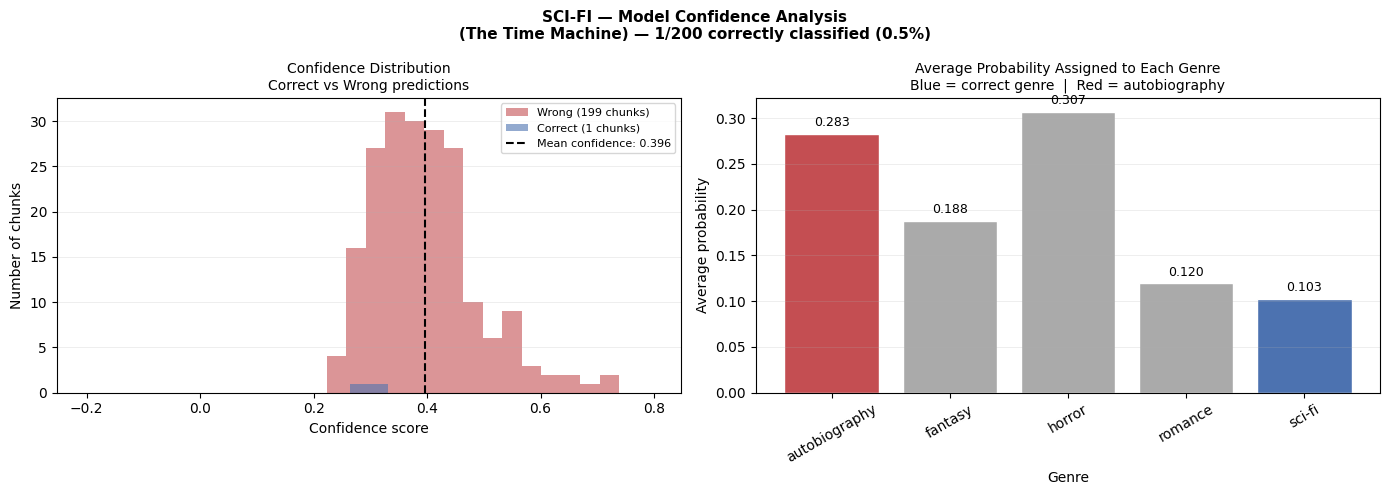


SCI-FI confidence summary:
  Correctly classified:       1/200 (0.5%)
  Avg confidence (correct):   0.2975
  Avg confidence (incorrect): 0.3966
  Avg probability for sci-fi: 0.1029
  Avg probability for autobiography: 0.2829


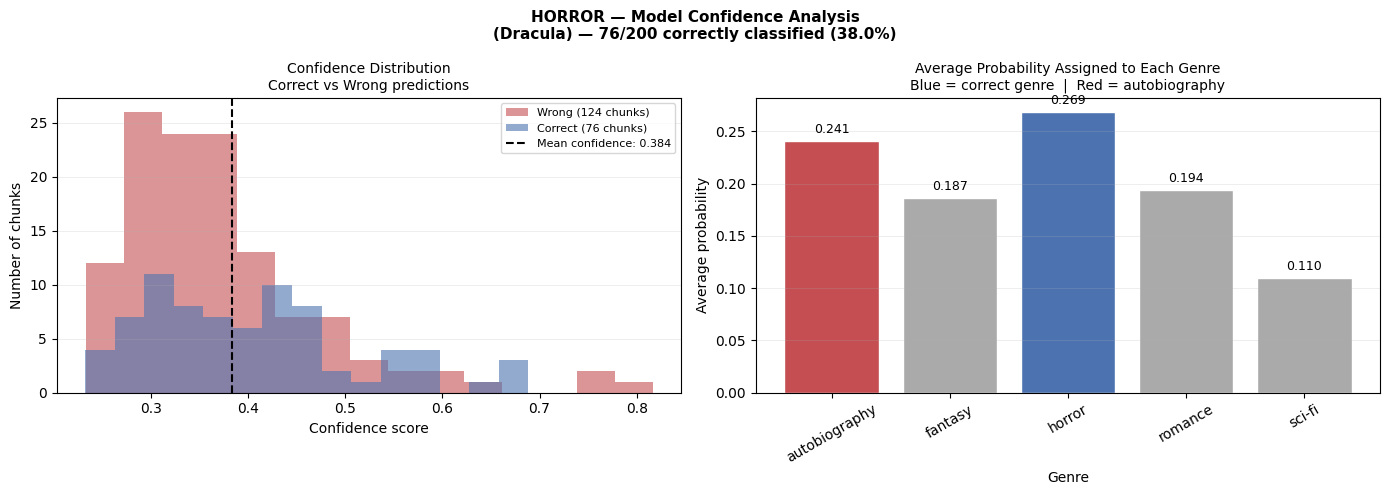


HORROR confidence summary:
  Correctly classified:       76/200 (38.0%)
  Avg confidence (correct):   0.4043
  Avg confidence (incorrect): 0.3713
  Avg probability for horror: 0.2687
  Avg probability for autobiography: 0.2410


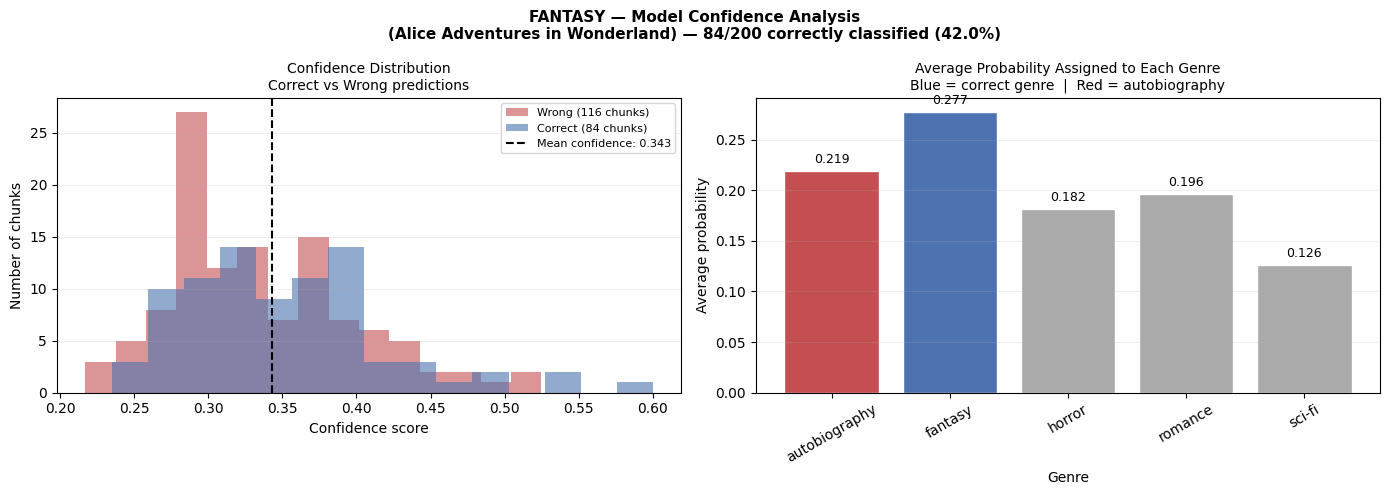


FANTASY confidence summary:
  Correctly classified:       84/200 (42.0%)
  Avg confidence (correct):   0.3514
  Avg confidence (incorrect): 0.3365
  Avg probability for fantasy: 0.2772
  Avg probability for autobiography: 0.2187


In [134]:
def plot_perspective2(genre, unseen_file):
    """
    Analyse LR confidence on misclassified chunks.
    Shows confidence distribution and average probability
    assigned to each genre across all chunks.
    """
    text   = load_and_clean_text(unseen_file)
    chunks = get_chunks_from_text(text)

    X_unseen      = vectorizer.transform(chunks)
    predictions   = lr.predict(X_unseen)
    probabilities = lr.predict_proba(X_unseen)

    results = pd.DataFrame(probabilities, columns=lr.classes_)
    results['predicted']  = predictions
    results['correct']    = predictions == genre
    results['confidence'] = probabilities.max(axis=1)
    results['true_prob']  = results[genre]

    correct_count  = results['correct'].sum()
    correct_conf   = results[results['correct']]['confidence'].mean() if results['correct'].any() else 0
    incorrect_conf = results[~results['correct']]['confidence'].mean() if (~results['correct']).any() else 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'{genre.upper()} — Model Confidence Analysis\n'
        f'({unseen_file.replace(".txt","")}) — '
        f'{correct_count}/200 correctly classified ({correct_count/2:.1f}%)',
        fontsize=11, fontweight='bold'
    )

    # Plot 1 — confidence distribution correct vs wrong
    correct   = results[results['correct']]['confidence']
    incorrect = results[~results['correct']]['confidence']

    axes[0].hist(incorrect, bins=15, alpha=0.6, color='#C44E52',
                label=f'Wrong ({len(incorrect)} chunks)')
    axes[0].hist(correct,   bins=15, alpha=0.6, color='#4C72B0',
                label=f'Correct ({len(correct)} chunks)')
    axes[0].axvline(results['confidence'].mean(), color='black',
                   linewidth=1.5, linestyle='--',
                   label=f'Mean confidence: {results["confidence"].mean():.3f}')
    axes[0].set_title('Confidence Distribution\nCorrect vs Wrong predictions', fontsize=10)
    axes[0].set_xlabel('Confidence score')
    axes[0].set_ylabel('Number of chunks')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', alpha=0.3)

    # Plot 2 — average probability assigned to each genre
    avg_probs = results[lr.classes_].mean()
    colors    = ['#4C72B0' if g == genre else
                 '#C44E52' if g == 'autobiography' else '#aaaaaa'
                 for g in lr.classes_]

    bars = axes[1].bar(lr.classes_, avg_probs, color=colors, edgecolor='white')
    for bar, val in zip(bars, avg_probs):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9
        )
    axes[1].set_title(
        'Average Probability Assigned to Each Genre\n'
        'Blue = correct genre  |  Red = autobiography',
        fontsize=10
    )
    axes[1].set_xlabel('Genre')
    axes[1].set_ylabel('Average probability')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'perspective2_{genre}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n{genre.upper()} confidence summary:")
    print(f"  Correctly classified:       {correct_count}/200 ({correct_count/2:.1f}%)")
    print(f"  Avg confidence (correct):   {correct_conf:.4f}")
    print(f"  Avg confidence (incorrect): {incorrect_conf:.4f}")
    print(f"  Avg probability for {genre}: {results[genre].mean():.4f}")
    print(f"  Avg probability for autobiography: {results['autobiography'].mean():.4f}")

    return results

# Run for three most confused genres
p2_results = {}
for genre in ['sci-fi', 'horror', 'fantasy']:
    unseen_file = [f for f, g in UNSEEN_BOOKS.items() if g == genre][0]
    p2_results[genre] = plot_perspective2(genre, unseen_file)

In [135]:
print("\nPerspective 2 Summary — Model Confidence (Logistic Regression)")
print("=" * 75)
print(f"{'Genre':<12} {'Correct%':>10} {'Conf(correct)':>15} {'Conf(wrong)':>13} {'True prob':>11} {'Auto prob':>11}")
print("-" * 75)

for genre, results in p2_results.items():
    correct_pct    = results['correct'].mean() * 100
    correct_conf   = results[results['correct']]['confidence'].mean() if results['correct'].any() else 0
    incorrect_conf = results[~results['correct']]['confidence'].mean() if (~results['correct']).any() else 0
    true_prob      = results[genre].mean()
    auto_prob      = results['autobiography'].mean()
    print(f"{genre:<12} {correct_pct:>9.1f}% {correct_conf:>15.4f} {incorrect_conf:>13.4f} {true_prob:>11.4f} {auto_prob:>11.4f}")


Perspective 2 Summary — Model Confidence (Logistic Regression)
Genre          Correct%   Conf(correct)   Conf(wrong)   True prob   Auto prob
---------------------------------------------------------------------------
sci-fi             0.5%          0.2975        0.3966      0.1029      0.2829
horror            38.0%          0.4043        0.3713      0.2687      0.2410
fantasy           42.0%          0.3514        0.3365      0.2772      0.2187
